# Days 11-20: Hypothesis Testing

Same dataset as `DIS.ipynb` (laptop prices, 19 columns per `describe.csv`), different job:
this notebook is not about summarizing the data, it's about making formal claims and
trying to break them before you believe them.

**Non-negotiable rule for every test below:**

1. State H0/H1 and pick α **before** looking at the result.
2. Decide one-tailed vs. two-tailed **before** looking at the result, based on the
   question — not after seeing which direction the data leans.
3. Check the assumptions the test actually needs, not the ones that are convenient.
4. Report effect size next to every p-value.
5. If more than one test touches the same dataset, correct for multiple comparisons
   at the end — not as an afterthought you can skip if the uncorrected result looks nice.

If you skip step 1 or 2 after already knowing the answer, you're not testing a
hypothesis anymore. You're decorating a foregone conclusion with a p-value.

## 1. Imports

In [1]:
%run ../Imports.py

In [2]:
# Hypothesis-testing-specific additions on top of Imports.py
from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.power import TTestIndPower, FTestAnovaPower
import warnings
warnings.filterwarnings("ignore")

## 2. Data

Columns per `describe.csv`:

| Column | Type | Column | Type |
|---|---|---|---|
| Company | str | ScreenRes_width | float |
| TypeName | str | ScreenRes_height | float |
| OpSys | str | Inches | float |
| RAM_GB | float | TouchScreen | str |
| GPU / GPU_Brand | str | Memory_Type1 / Memory_Size1_GB | str/float |
| CPU_model / CPU_GHz | str/float | Memory_Type2 / Memory_Size2_GB | str/float |
| Weight_KG | float | Price_Rupee | float |


In [3]:
from pathlib import Path

data_path = Path("../D_1_10/Data/laptopData_cleaned.csv")
df = pd.read_csv(data_path)

print(df.shape)
df.head()

(1271, 18)


,Company,TypeName,OpSys,RAM_GB,GPU,GPU_Brand,CPU_model,CPU_GHz,Weight_KG,Price_Rupee,ScreenRes_width,ScreenRes_height,Inches,TouchScreen,Memory_Type1,Memory_Size1_GB,Memory_Type2,Memory_Size2_GB
0,Apple,Ultrabook,macOS,8,Intel Iris Plus Graphics 640,Intel,Intel Core i5,2.3,1.37,71378.6832,2560,1600,13.3,No,SSD,128,No second memory,0
1,Apple,Ultrabook,macOS,8,Intel HD Graphics 6000,Intel,Intel Core i5,1.8,1.34,47895.5232,1440,900,13.3,No,Flash Storage,128,No second memory,0
2,HP,Notebook,No OS,8,Intel HD Graphics 620,Intel,Intel Core i5 7200U,2.5,1.86,30636.0000,1920,1080,15.6,No,SSD,256,No second memory,0
3,Apple,Ultrabook,macOS,16,AMD Radeon Pro 455,AMD,Intel Core i7,2.7,1.83,135195.3360,2880,1800,15.4,No,SSD,512,No second memory,0
4,Apple,Ultrabook,macOS,8,Intel Iris Plus Graphics 650,Intel,Intel Core i5,3.1,1.37,96095.8080,2560,1600,13.3,No,SSD,256,No second memory,0


In [4]:
# Minimum viable sanity check. Skip this and any "significant" result downstream
# is only as trustworthy as a dataset you never actually looked at.
print("Duplicated rows:", df.duplicated().sum())
print()
print("Nulls per column:")
print(df.isna().sum().sort_values(ascending=False))

Duplicated rows: 29

Nulls per column:
Company             0
TypeName            0
OpSys               0
RAM_GB              0
GPU                 0
GPU_Brand           0
CPU_model           0
CPU_GHz             0
Weight_KG           0
Price_Rupee         0
ScreenRes_width     0
ScreenRes_height    0
Inches              0
TouchScreen         0
Memory_Type1        0
Memory_Size1_GB     0
Memory_Type2        0
Memory_Size2_GB     0
dtype: int64


## 3. Framework — fixed before any test runs

Set once, applies to every test in this notebook unless explicitly overridden:

- **α (Type I error rate):** 0.05 per test, before correction.
- **Type I error:** rejecting H0 when it's actually true — a false "there's an effect."
- **Type II error (β):** failing to reject H0 when it's actually false — missing a real effect,
  usually because of small n or noisy data. Nobody talks about this one until their test
  comes back non-significant and they need an excuse; check power *before* running the test,
  not after, so the excuse doesn't get to be a surprise.
- **Multiple comparisons:** every test below is tracked in `test_registry` and corrected
  together at the end (Section 8). No test's significance is final until that correction
  is applied.

In [5]:
# Registry to hold every p-value produced in this notebook, for the correction step at the end.
test_registry = []  # list of dicts: {"name": ..., "p": ...}

def register(name, p):
    test_registry.append({"name": name, "p": p})
    print(f"Registered: {name} (p={p:.4f})")

## 4. One-sample t-test — is the average laptop price different from a claimed benchmark?

**Claim to test:** a market report / prior study claims the average laptop price is
**60,000 Rupee**. Does this sample contradict that?

- **H0:** μ = 60,000
- **H1:** μ ≠ 60,000 (two-tailed — no directional reason to expect only "higher" or only "lower")
- **α = 0.05**

Assumption this test needs: the sampling distribution of the mean is approximately
normal. With n this large, CLT covers you even if the raw price distribution is skewed
(and Section 3 of `DIS.ipynb` already showed it is) — but check n and skew together, not
n alone.

In [6]:
price = df["Price_Rupee"].dropna()
n = len(price)
skew = price.skew()

print(f"n = {n}, skew = {skew:.2f}")
print("CLT bailout is reasonable here" if n >= 30 else "n is small — do not trust CLT, use a non-parametric alternative")

benchmark = 60000
t_stat, p_val = stats.ttest_1samp(price, popmean=benchmark)

# Effect size: Cohen's d for one-sample test
d = (price.mean() - benchmark) / price.std(ddof=1)

print(f"\nSample mean: {price.mean():,.2f}")
print(f"t={t_stat:.3f}, p={p_val:.4f}")
print(f"Cohen's d = {d:.3f}")

register("one_sample_t_price_vs_60000", p_val)

n = 1271, skew = 1.54
CLT bailout is reasonable here

Sample mean: 59,888.47
t=-0.107, p=0.9151
Cohen's d = -0.003
Registered: one_sample_t_price_vs_60000 (p=0.9151)


**Read it straight:** a large n makes it trivially easy to hit p < 0.05 on a tiny,
practically meaningless deviation from 60,000. That's exactly why Cohen's d is sitting
right next to the p-value — if `d` is under ~0.2, the "statistically significant"
difference isn't one you'd notice or care about outside a stats notebook.

## 5. Two-sample test — does `TouchScreen` change price?

**H0:** mean price is equal between touchscreen and non-touchscreen laptops.
**H1:** they differ (two-tailed — you have no strong prior on direction before looking).
**α = 0.05**

Assumptions this test needs: normality within each group, and either equal variances
(Student's t) or not (Welch's t, the safer default). Check both, decide the test
**before** looking at the p-value each branch would produce.

In [7]:
grp_yes = df.loc[df["TouchScreen"] == "Yes", "Price_Rupee"].dropna()
grp_no  = df.loc[df["TouchScreen"] == "No",  "Price_Rupee"].dropna()

print("n(touch) =", len(grp_yes), " n(no touch) =", len(grp_no))

for name, grp in [("TouchScreen=Yes", grp_yes), ("TouchScreen=No", grp_no)]:
    stat, p = stats.shapiro(grp)
    print(f"Shapiro-Wilk {name}: p={p:.4f}", "-> NOT normal" if p < 0.05 else "-> normal-ish")

lev_stat, lev_p = stats.levene(grp_yes, grp_no)
print(f"\nLevene's test: p={lev_p:.4f}", "-> unequal variances, use Welch's" if lev_p < 0.05 else "-> variances OK")

n(touch) = 185  n(no touch) = 1086
Shapiro-Wilk TouchScreen=Yes: p=0.0000 -> NOT normal
Shapiro-Wilk TouchScreen=No: p=0.0000 -> NOT normal

Levene's test: p=0.0231 -> unequal variances, use Welch's


**Pre-committed decision rule** (write this down before running the next cell,
not after seeing which test gives the nicer number):
- Normality holds + equal variances → Student's t-test.
- Normality holds, unequal variances → Welch's t-test.
- Normality fails, n reasonably large per group → Welch's t-test is still defensible (CLT).
- Normality fails, n small → Mann-Whitney U instead, full stop.

In [8]:
t_stat, t_p = stats.ttest_ind(grp_yes, grp_no, equal_var=False)  # Welch's, per the rule above

pooled_sd = np.sqrt(((len(grp_yes) - 1) * grp_yes.std(ddof=1) ** 2 +
                      (len(grp_no) - 1) * grp_no.std(ddof=1) ** 2) /
                     (len(grp_yes) + len(grp_no) - 2))
cohens_d = (grp_yes.mean() - grp_no.mean()) / pooled_sd

print(f"Welch's t-test: t={t_stat:.3f}, p={t_p:.4f}")
print(f"Cohen's d = {cohens_d:.3f}")

register("two_sample_touchscreen_price", t_p)

# Non-parametric cross-check, run regardless so a normality failure doesn't go unnoticed
u_stat, u_p = stats.mannwhitneyu(grp_yes, grp_no, alternative="two-sided")
print(f"\nMann-Whitney U cross-check: p={u_p:.4f}")
if (t_p < 0.05) != (u_p < 0.05):
    print("WARNING: parametric and non-parametric tests disagree on significance — trust the normality check above to break the tie.")

Welch's t-test: t=6.189, p=0.0000
Cohen's d = 0.548
Registered: two_sample_touchscreen_price (p=0.0000)

Mann-Whitney U cross-check: p=0.0000


### 5.1 Power check — could this test have detected the effect if it existed?

If the result above came back non-significant, before concluding "no effect," check
whether the test even had a fair shot. An underpowered non-result is not evidence of
"no difference" — it's evidence of "we didn't look hard enough".

In [9]:
power_analysis = TTestIndPower()
achieved_power = power_analysis.power(effect_size=cohens_d, nobs1=len(grp_yes),
                                       ratio=len(grp_no) / len(grp_yes), alpha=0.05)
print(f"Achieved power at the observed effect size: {achieved_power:.3f}")
print("Below 0.80 -> treat a non-significant result here as inconclusive, not as proof of no effect."
      if achieved_power < 0.80 else "Adequately powered.")

Achieved power at the observed effect size: 1.000
Adequately powered.


## 6. Correlation test — CPU speed vs. price

**H0:** ρ = 0 (no linear association between `CPU_GHz` and `Price_Rupee`).
**H1:** ρ ≠ 0.
**α = 0.05**

Pearson assumes roughly linear relationship and no small set of outliers driving the
whole result — check the scatter before trusting the number.

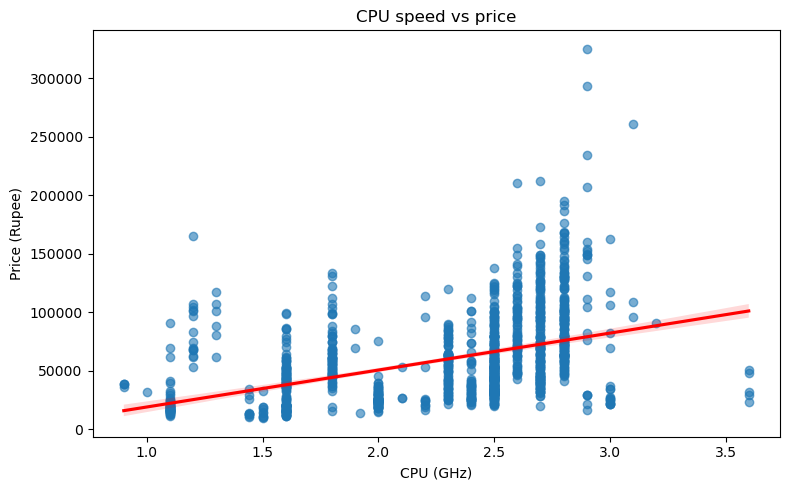

In [10]:
sub = df[["CPU_GHz", "Price_Rupee"]].dropna()

fig, ax = plt.subplots(figsize=(8, 5))
sns.regplot(data=sub, x="CPU_GHz", y="Price_Rupee", ax=ax,
            scatter_kws={"alpha": 0.6}, line_kws={"color": "red"})
ax.set_xlabel("CPU (GHz)")
ax.set_ylabel("Price (Rupee)")
ax.set_title("CPU speed vs price")
plt.tight_layout()
# plt.savefig("../Results/cpu_vs_price.png", dpi=600, bbox_inches="tight")
plt.show()

In [11]:
pearson_r, pearson_p = stats.pearsonr(sub["CPU_GHz"], sub["Price_Rupee"])
spearman_r, spearman_p = stats.spearmanr(sub["CPU_GHz"], sub["Price_Rupee"])

print(f"Pearson  r={pearson_r:.3f}, p={pearson_p:.4f}")
print(f"Spearman r={spearman_r:.3f}, p={spearman_p:.4f}  (monotonic only, no linearity assumption)")

register("correlation_cpu_price", pearson_p)

if abs(pearson_r - spearman_r) > 0.1:
    print("\nWARNING: Pearson and Spearman disagree noticeably -> relationship likely isn't linear, quote Spearman instead.")

Pearson  r=0.429, p=0.0000
Spearman r=0.528, p=0.0000  (monotonic only, no linearity assumption)
Registered: correlation_cpu_price (p=0.0000)


**Do not let this test imply causation.** CPU speed and price both track the same
latent variable — how premium the machine is overall. A significant correlation here
says nothing about what happens to price if you swap only the CPU and hold everything
else fixed. That question needs a controlled comparison or a regression that holds RAM,
GPU, and weight constant — not a bivariate correlation.

## 7. ANOVA — does `Company` explain price differences?

**H0:** all brands have equal mean price.
**H1:** at least one brand differs.
**α = 0.05**

Brands with fewer than 5 observations are excluded **before** running the test — that
threshold is set now, not adjusted later depending on which brands turn out significant.

In [12]:
groups = [g["Price_Rupee"].dropna().values for _, g in df.groupby("Company") if len(g) >= 5]
labels = [name for name, g in df.groupby("Company") if len(g) >= 5]
excluded = [name for name, g in df.groupby("Company") if len(g) < 5]

print("Brands included (n >= 5):", labels)
print("Brands excluded for insufficient n:", excluded)

Brands included (n >= 5): ['Acer', 'Apple', 'Asus', 'Dell', 'HP', 'Lenovo', 'MSI', 'Mediacom', 'Microsoft', 'Razer', 'Samsung', 'Toshiba']
Brands excluded for insufficient n: ['Chuwi', 'Fujitsu', 'Google', 'Huawei', 'LG', 'Vero', 'Xiaomi']


In [13]:
lev_stat, lev_p = stats.levene(*groups)
print(f"Levene's test across brands: p={lev_p:.4f}",
      "-> heteroscedastic, ANOVA result is at risk" if lev_p < 0.05 else "-> variances OK")

f_stat, f_p = stats.f_oneway(*groups)
print(f"\nOne-way ANOVA: F={f_stat:.3f}, p={f_p:.4f}")

grand_mean = np.concatenate(groups).mean()
ss_between = sum(len(g) * (g.mean() - grand_mean) ** 2 for g in groups)
ss_total = sum(((g - grand_mean) ** 2).sum() for g in groups)
eta_sq = ss_between / ss_total
print(f"Eta-squared = {eta_sq:.3f}")

register("anova_price_by_company", f_p)

Levene's test across brands: p=0.0000 -> heteroscedastic, ANOVA result is at risk

One-way ANOVA: F=20.123, p=0.0000
Eta-squared = 0.152
Registered: anova_price_by_company (p=0.0000)


**Eta-squared is the honesty check here.** A significant F-statistic with a small
eta-squared means brand explains a sliver of price variance — real, but not the main
story. Specs are almost certainly doing most of the work; don't write "brand drives
price" in a conclusion unless eta-squared backs that up.

An ANOVA only tells you *some* group differs, not which. If it's significant, the
post-hoc below is mandatory — running unadjusted pairwise t-tests instead would inflate
the false-positive rate across all those brand pairs.

In [14]:
if f_p < 0.05:
    flat_df = df[df["Company"].isin(labels)][["Company", "Price_Rupee"]].dropna()
    tukey = pairwise_tukeyhsd(endog=flat_df["Price_Rupee"], groups=flat_df["Company"], alpha=0.05)
    print(tukey)
else:
    print("ANOVA not significant at alpha=0.05 -> no post-hoc test is justified. Stop here, don't go fishing for a significant pair anyway.")

          Multiple Comparison of Means - Tukey HSD, FWER=0.05          
  group1    group2    meandiff   p-adj     lower        upper    reject
-----------------------------------------------------------------------
     Acer     Apple   49945.8839    0.0   22885.1167  77006.6511   True
     Acer      Asus   25577.7578    0.0   11228.5973  39926.9182   True
     Acer      Dell    29565.158    0.0   16571.4727  42558.8432   True
     Acer        HP   23819.7555    0.0   10703.4575  36936.0535   True
     Acer    Lenovo   24677.8612    0.0   11713.9459  37641.7766   True
     Acer       MSI   58419.9329    0.0   39314.2188   77525.647   True
     Acer  Mediacom   -17677.016 0.9777  -61822.4949  26468.4629  False
     Acer Microsoft    52509.172 0.0159    5043.8389  99974.5052   True
     Acer     Razer  144887.8755    0.0  100742.3966 189033.3543   True
     Acer   Samsung    41913.704 0.0248    2628.7123  81198.6958   True
     Acer   Toshiba   33352.7542    0.0    13458.136  53247.3725

## 8. Multiple comparisons correction

Four hypotheses were tested against the same dataset in Sections 4-7. At α=0.05 each,
the probability of at least one false positive across all four by chance alone is:

**1 - (0.95)^4 ≈ 18.5%** — not 5%.

Bonferroni (conservative, controls family-wise error rate) and Benjamini-Hochberg
(less conservative, controls false discovery rate) below, applied to everything logged
in `test_registry`. A result that survives raw α=0.05 but not this step does not get
reported as significant.

In [15]:
names = [t["name"] for t in test_registry]
pvals = [t["p"] for t in test_registry]

bonf_reject, bonf_corrected, _, _ = multipletests(pvals, alpha=0.05, method="bonferroni")
bh_reject, bh_corrected, _, _ = multipletests(pvals, alpha=0.05, method="fdr_bh")

summary = pd.DataFrame({
    "test": names,
    "raw_p": pvals,
    "bonferroni_p": bonf_corrected,
    "bonferroni_reject_H0": bonf_reject,
    "benjamini_hochberg_p": bh_corrected,
    "bh_reject_H0": bh_reject
})
summary

,test,raw_p,bonferroni_p,bonferroni_reject_H0,benjamini_hochberg_p,bh_reject_H0
0,one_sample_t_price_vs_60000,9.151472e-01,1.000000e+00,False,9.151472e-01,False
1,two_sample_touchscreen_price,2.712887e-09,1.085155e-08,True,3.617183e-09,True
2,correlation_cpu_price,5.223786e-58,2.089514e-57,True,2.089514e-57,True
3,anova_price_by_company,9.183468e-38,3.673387e-37,True,1.836694e-37,True


## 9. Stress test — what breaks if someone pushes back on this notebook

- **"You ran the test both ways (Welch's and Mann-Whitney) and picked one" —** no,
  Section 5 pre-committed to a decision rule based on the normality/Levene checks
  *before* either test ran. If that rule wasn't actually written down before you ran the
  cell, this notebook's biggest claim to rigor is fake and Section 5 needs to be redone
  with the rule fixed first.
- **"Is 60,000 Rupee benchmark in Section 4 real or made up?"** — if it's not from an
  actual market report, the whole one-sample test is testing a hypothesis nobody
  actually holds. Replace it with a real number before this goes anywhere.
- **Power, not just significance:** Section 5.1 checked power for one test. The
  correlation and ANOVA sections didn't get the same treatment — if either comes back
  non-significant, that absence of power check means "no effect" and "underpowered
  test" are indistinguishable. Fix before trusting a null result from Sections 6 or 7.
- **After correction, re-read Section 8's table before repeating any claim from
  Sections 4-7 out loud.** A result that was p=0.04 raw and p=0.16 after
  Benjamini-Hochberg is not significant anymore, no matter how good the effect size
  looked in isolation.
- **Sampling assumption, unresolved:** every CI, t-test, and ANOVA above assumes this
  Kaggle scrape behaves like a random sample of some population of laptops. Nobody
  verified that, and it's not verifiable from the data itself. State it as an open
  assumption, not a settled fact, in any write-up.
- **Next real test to run, not a nice-to-have:** a multiple regression with RAM_GB,
  CPU_GHz, Weight_KG, and GPU_Brand predicting Price_Rupee would tell you whether
  CPU_GHz in Section 6 still matters once the other specs are held constant. Until
  that's run, "CPU speed is associated with price" is the only defensible claim —
  not "CPU speed drives price."
